# Data Cleaning

In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from gutenbergpy.gutenbergcache import GutenbergCache, GutenbergCacheSettings

In [10]:
cache = GutenbergCache.get_cache()
data_dir = os.path.abspath(os.path.join("..", "data", "gutenberg_catalog_cache"))

GutenbergCacheSettings.set(
    CacheFilename=os.path.join(data_dir, "gutenbergindex.db"),
    CacheUnpackDir=os.path.join(data_dir, "epub"),
)


print(GutenbergCacheSettings.CACHE_FILENAME)
print(GutenbergCacheSettings.CACHE_RDF_UNPACK_DIRECTORY)


/Users/ethanleitch/Documents/Coding_Projects/Socrates_AI/data/gutenberg_catalog_cache/gutenbergindex.db
/Users/ethanleitch/Documents/Coding_Projects/Socrates_AI/data/gutenberg_catalog_cache/epub


In [11]:
books = pd.DataFrame(
    cache.native_query("SELECT * FROM books").fetchall(),
    columns=[
        "id",
        "publisherid",
        "dateissued",
        "rightsid",
        "numdownloads",
        "languageid",
        "bookshelfid",
        "gutenbergbookid",
        "typeid",
    ],
)

titles = pd.DataFrame(
    cache.native_query("SELECT * FROM titles").fetchall(),
    columns=["id", "name", "bookid"],
)

authors = pd.DataFrame(
    cache.native_query("SELECT * FROM authors").fetchall(),
    columns=["id", "name"],
)

subjects = pd.DataFrame(
    cache.native_query("SELECT * FROM subjects").fetchall(),
    columns=["id", "name"],
)

languages = pd.DataFrame(
    cache.native_query("SELECT * FROM languages").fetchall(),
    columns=["id", "name"],
)

publishers = pd.DataFrame(
    cache.native_query("SELECT * FROM publishers").fetchall(),
    columns=["id", "name"],
)

rights = pd.DataFrame(
    cache.native_query("SELECT * FROM rights").fetchall(),
    columns=["id", "name"],
)

types = pd.DataFrame(
    cache.native_query("SELECT * FROM types").fetchall(),
    columns=["id", "name"],
)

bookshelves = pd.DataFrame(
    cache.native_query("SELECT * FROM bookshelves").fetchall(),
    columns=["id", "name"],
)

downloadlinks = pd.DataFrame(
    cache.native_query("SELECT * FROM downloadlinks").fetchall(),
    columns=["id", "name", "downloadtypeid", "bookid"],
)

downloadlinkstype = pd.DataFrame(
    cache.native_query("SELECT * FROM downloadlinkstype").fetchall(),
    columns=["id", "name"],
)

book_authors = pd.DataFrame(
    cache.native_query("SELECT * FROM book_authors").fetchall(),
    columns=["bookid", "authorid"],
)

book_subjects = pd.DataFrame(
    cache.native_query("SELECT * FROM book_subjects").fetchall(),
    columns=["bookid", "subjectid"],
)

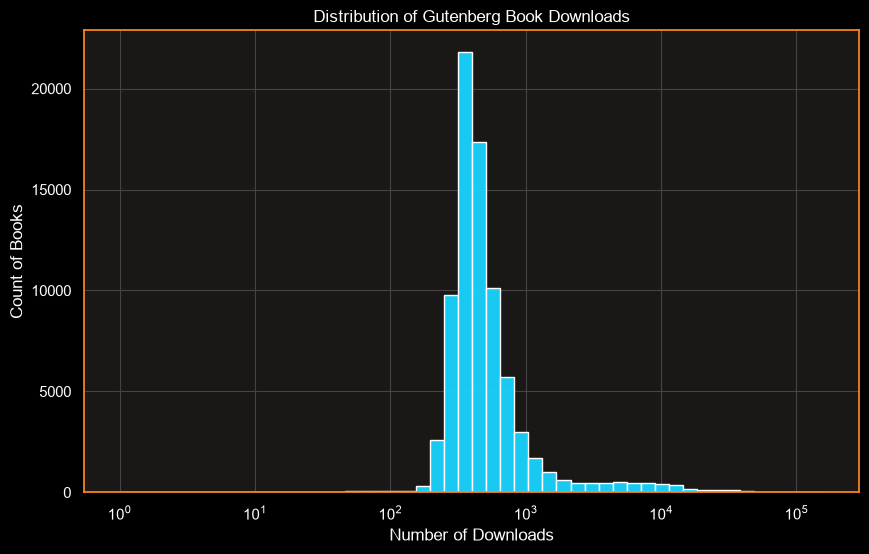

In [81]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6))

# Outside plot background (figure)
fig.patch.set_facecolor("#000000")   # lighter dark grey

# Inside plot background (axes)
ax.set_facecolor("#1A1817")           # almost black

# Histogram
sns.histplot(
    books["numdownloads"],
    bins=50,
    log_scale=True,
    color="#18D5FFFF",
    ax=ax,
    alpha = 0.95
)

# Grid styling
ax.grid(
    True,
    color="#444444",   # slightly lighter than axes
    linewidth=0.8
)

# Spines
for spine in ax.spines.values():
    spine.set_color("#FF8818")

# Text
ax.set_title("Distribution of Gutenberg Book Downloads")
ax.set_xlabel("Number of Downloads")
ax.set_ylabel("Count of Books")

plt.show()

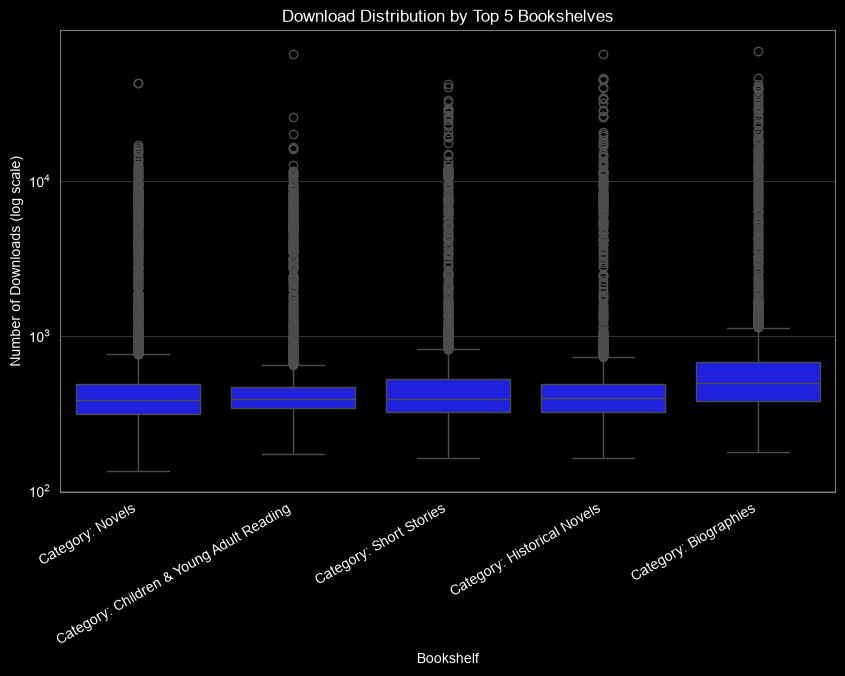

In [37]:
# merge books with bookshelves to get readable names
books_with_shelf = books.merge(bookshelves, left_on="bookshelfid", right_on="id", suffixes=("", "_shelf"))

# find top 5 bookshelves by number of books
top5_shelves = books_with_shelf["name"].value_counts().head(5).index

plot_data = books_with_shelf[books_with_shelf["name"].isin(top5_shelves)]

plt.style.use("dark_background")
sns.set_style({"grid.color": "0.2"})

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=plot_data, x="name", y="numdownloads", color="blue")
ax.set_yscale("log")

for spine in ax.spines.values():
    spine.set_color("0.5")

plt.title("Download Distribution by Top 5 Bookshelves")
plt.xlabel("Bookshelf")
plt.ylabel("Number of Downloads (log scale)")
plt.xticks(rotation=30, ha="right")
plt.show()

In [83]:
ALPHABET = list("abcdefghijklmnopqrstuvwxyz .,!?;:'\"()-\n")
VOCAB = {ch:i for i,ch in enumerate(ALPHABET)} # returns an integer given a character
INV_VOCAB = {i:ch for ch,i in VOCAB.items()} # returns a character given an integer
L = len(ALPHABET)

In [84]:
def load_text(path: str) -> str:
    """
      Load and clean a text file into a single lowercase string
      restricted to the model's alphabet.

      Steps:
        1. Read the file as UTF-8 text.
        2. Convert everything to lowercase (since the alphabet is lowercase only).
        3. Replace any character with something appropriate from the alphabet.
        4. Return the cleaned text as a single string.
    """
    with open(path, "r", encoding="utf-8") as f:
        txt = f.read().lower()
    # [TODO]
    return "".join(ch if ch in ALPHABET else " " for ch in txt)

In [86]:
data_dir = os.path.join("..", "data", "raw_books")

load_text(data_dir + "/7205.txt")

'\ncover\n\n\n\n\nalso sprach zarathustra\n\nein buch f r alle und keinen\n\nvon friedrich wilhelm nietzsche\n\n\n\n\ninhaltsverzeichnis\n\n\n erster theil\n zarathustra s vorrede\n die reden zarathustra s\n von den drei verwandlungen\n von den lehrst hlen der tugend\n von den hinterweltlern\n von den ver chtern des leibes\n von den freuden- und leidenschaften\n vom bleichen verbrecher\n vom lesen und schreiben\n vom baum am berge\n von den predigern des todes\n vom krieg und kriegsvolke\n vom neuen g tzen\n von den fliegen des marktes\n von der keuschheit\n vom freunde\n von tausend und einem ziele\n von der n chstenliebe\n vom wege des schaffenden\n von alten und jungen weiblein\n vom biss der natter\n von kind und ehe\n vom freien tode\n von der schenkenden tugend\n\n zweiter theil\n das kind mit dem spiegel\n auf den gl ckseligen inseln\n von den mitleidigen\n von den priestern\n von den tugendhaften\n vom gesindel\n von den taranteln\n von den ber hmten weisen\n das nachtlied\n da